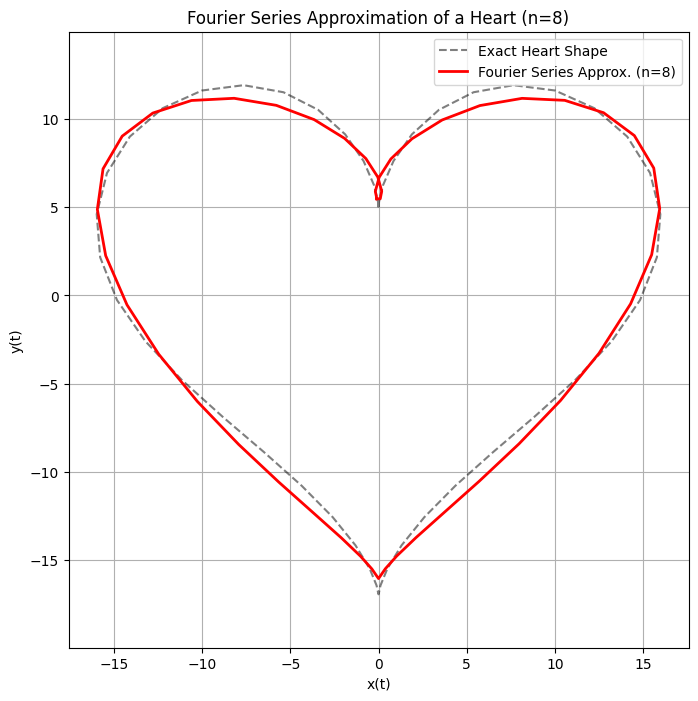

In [15]:

import numpy as np
import matplotlib.pyplot as plt

# Number of Fourier terms
n_terms = 8  # You can adjust this value to increase accuracy

# Define the time parameter t (from 0 to 2*pi)
num_points = 50  # Number of points for plotting and DFT
t = np.linspace(0, 2 * np.pi, num_points)

# Define the exact parametric heart shape
x_exact = 16 * np.sin(t)**3
y_exact = 13 * np.cos(t) - 5 * np.cos(2*t) - 2 * np.cos(3*t) - np.cos(4*t)

# Perform a Discrete Fourier Transform (DFT) to get the Fourier coefficients
def compute_fourier_coefficients(signal, n_terms):
    # Compute the DFT of the signal using numpy's FFT
    fft_coeffs = np.fft.fft(signal) / len(signal)
    
    # We only need the first n_terms/2 positive frequencies (real and imaginary parts)
    # We take real and imaginary parts to construct cosine and sine terms
    a_coeffs = 2 * fft_coeffs.real[:n_terms//2]
    b_coeffs = -2 * fft_coeffs.imag[:n_terms//2]
   
    # DC term (n=0) should not be doubled
    a_coeffs[0] = fft_coeffs.real[0]
    b_coeffs[0] = 0.0  # DC term for sine is always zero

    return a_coeffs, b_coeffs

# Compute Fourier coefficients for x(t) and y(t)
A_x, B_x = compute_fourier_coefficients(x_exact, n_terms)
A_y, B_y = compute_fourier_coefficients(y_exact, n_terms)

# Reconstruct the Fourier series approximation of the heart shape
x_approx = np.zeros_like(t)
y_approx = np.zeros_like(t)

# Add the Fourier series terms up to n_terms
for n in range(n_terms // 2):
    if n == 0:
        # DC term (n=0)
        x_approx += A_x[n]
        y_approx += A_y[n]
    else:
        # For n > 0, add cosine and sine terms
        x_approx += A_x[n] * np.cos(n * t) + B_x[n] * np.sin(n * t)
        y_approx += A_y[n] * np.cos(n * t) + B_y[n] * np.sin(n * t)

# Plot the exact heart shape and the Fourier series approximation
plt.figure(figsize=(8, 8))
plt.plot(x_exact, y_exact, 'k--', label='Exact Heart Shape', alpha=0.5)
plt.plot(x_approx, y_approx, 'r', label=f'Fourier Series Approx. (n={n_terms})', linewidth=2)
plt.title(f'Fourier Series Approximation of a Heart (n={n_terms})')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()